# Stage 4: Tokenization Analysis

This notebook compares baseline tokenizers (Stage 2) against custom biomedical tokenizers (Stage 3).

Outputs:
- quantitative metrics table,
- qualitative term split comparison,
- baseline-custom overlap summary,
- inline figures and tables in notebook output.

In [19]:
import os
import re
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from datasets import load_dataset
from IPython.display import display
from tokenizers import Tokenizer
from transformers import BertTokenizer, GPT2Tokenizer

In [20]:
RANDOM_SEED = 42
SAMPLE_SIZE = 300

TOKENIZERS_DIR = "../tokenizers"

TARGET_TERMS = [
    "nephrolithiasis",
    "gastroesophageal",
    "dermographism",
    "electrocardiogram",
    "immunohistochemistry",
    "acetylcholinesterase",
    "hypercholesterolemia",
    "hepatocellular",
    "neurodegenerative",
    "myocardial",
]

BASELINE_SPECS = {
    "bert_base": "bert-base-uncased",
    "biobert": "dmis-lab/biobert-base-cased-v1.1",
    "gpt2": "gpt2",
}

CUSTOM_SPECS = {
    "biomedical_bpe_30k": os.path.join(TOKENIZERS_DIR, "biomedical_bpe_30k.json"),
    "biomedical_bpe_50k": os.path.join(TOKENIZERS_DIR, "biomedical_bpe_50k.json"),
    "biomedical_bpe_100k": os.path.join(TOKENIZERS_DIR, "biomedical_bpe_100k.json"),
}

In [21]:
def get_context_text(context_field):
    if isinstance(context_field, dict):
        contexts = context_field.get("contexts", [])
        if isinstance(contexts, list):
            return " ".join(str(part) for part in contexts)
    if isinstance(context_field, list):
        return " ".join(str(part) for part in context_field)
    return str(context_field)


def count_words(text):
    return len(text.split())


def clean_token(token):
    return re.sub(r"^[\W_]+|[\W_]+$", "", token)


def evaluate_hf_tokenizer(tokenizer, texts):
    token_counts, word_counts = [], []
    char_lengths = []
    unk_count, total_tokens = 0, 0
    vocab_counter = Counter()

    unk_candidates = set()
    if tokenizer.unk_token is not None:
        unk_candidates.add(tokenizer.unk_token)
    if tokenizer.unk_token_id is not None:
        unk_candidates.add(tokenizer.convert_ids_to_tokens([tokenizer.unk_token_id])[0])

    for text in texts:
        token_ids = tokenizer(text, add_special_tokens=True)["input_ids"]
        tokens = tokenizer.convert_ids_to_tokens(token_ids)
        token_counts.append(len(tokens))
        word_counts.append(count_words(text))

        for token in tokens:
            total_tokens += 1
            vocab_counter[token] += 1
            if token in unk_candidates:
                unk_count += 1
            if token not in tokenizer.all_special_tokens:
                normalized = clean_token(token)
                if normalized:
                    char_lengths.append(len(normalized))

    return {
        "avg_tokens_per_sample": float(np.mean(token_counts)),
        "fertility": float(np.sum(token_counts) / max(np.sum(word_counts), 1)),
        "unk_rate": float(unk_count / max(total_tokens, 1)),
        "avg_token_length_chars": float(np.mean(char_lengths)) if char_lengths else 0.0,
        "top_tokens": vocab_counter.most_common(30),
    }


def evaluate_custom_tokenizer(custom_tokenizer, texts):
    token_counts, word_counts = [], []
    char_lengths = []
    unk_count, total_tokens = 0, 0
    vocab_counter = Counter()

    unk_token = "[UNK]"

    for text in texts:
        encoding = custom_tokenizer.encode(text)
        tokens = encoding.tokens
        token_counts.append(len(tokens))
        word_counts.append(count_words(text))

        for token in tokens:
            total_tokens += 1
            vocab_counter[token] += 1
            if token == unk_token:
                unk_count += 1
            if token not in {"[PAD]", "[UNK]", "[CLS]", "[SEP]", "[MASK]"}:
                normalized = clean_token(token)
                if normalized:
                    char_lengths.append(len(normalized))

    return {
        "avg_tokens_per_sample": float(np.mean(token_counts)),
        "fertility": float(np.sum(token_counts) / max(np.sum(word_counts), 1)),
        "unk_rate": float(unk_count / max(total_tokens, 1)),
        "avg_token_length_chars": float(np.mean(char_lengths)) if char_lengths else 0.0,
        "top_tokens": vocab_counter.most_common(30),
    }


def token_split_examples_hf(tokenizer, terms, tokenizer_name):
    rows = []
    for term in terms:
        ids = tokenizer(term, add_special_tokens=False)["input_ids"]
        pieces = tokenizer.convert_ids_to_tokens(ids)
        rows.append({"tokenizer_name": tokenizer_name, "term": term, "pieces": pieces, "n_pieces": len(pieces)})
    return pd.DataFrame(rows)


def token_split_examples_custom(tokenizer_obj, terms, tokenizer_name):
    rows = []
    for term in terms:
        pieces = tokenizer_obj.encode(term).tokens
        rows.append({"tokenizer_name": tokenizer_name, "term": term, "pieces": pieces, "n_pieces": len(pieces)})
    return pd.DataFrame(rows)

In [22]:
dataset = load_dataset("qiaojin/PubMedQA", "pqa_labeled")["train"]
df = pd.DataFrame(
    {
        "question": dataset["question"],
        "context_text": [get_context_text(x) for x in dataset["context"]],
    }
)
df["text"] = df["question"].fillna("") + " [SEP] " + df["context_text"].fillna("")
sample_df = df.sample(n=min(SAMPLE_SIZE, len(df)), random_state=RANDOM_SEED).reset_index(drop=True)
sample_texts = sample_df["text"].tolist()

print(f"Evaluation sample size: {len(sample_texts)}")

Evaluation sample size: 300


In [23]:
baseline_tokenizers = {
    "bert_base": BertTokenizer.from_pretrained(BASELINE_SPECS["bert_base"]),
    "biobert": BertTokenizer.from_pretrained(BASELINE_SPECS["biobert"]),
    "gpt2": GPT2Tokenizer.from_pretrained(BASELINE_SPECS["gpt2"]),
}

custom_tokenizers = {
    name: Tokenizer.from_file(path)
    for name, path in CUSTOM_SPECS.items()
}

list(baseline_tokenizers.keys()), list(custom_tokenizers.keys())

(['bert_base', 'biobert', 'gpt2'],
 ['biomedical_bpe_30k', 'biomedical_bpe_50k', 'biomedical_bpe_100k'])

In [24]:
metrics_rows = []
examples_tables = []
top_tokens_summary = {}

for name, tok in baseline_tokenizers.items():
    m = evaluate_hf_tokenizer(tok, sample_texts)
    metrics_rows.append(
        {
            "tokenizer_name": name,
            "tokenizer_family": "baseline",
            "avg_tokens_per_sample": m["avg_tokens_per_sample"],
            "fertility": m["fertility"],
            "unk_rate": m["unk_rate"],
            "avg_token_length_chars": m["avg_token_length_chars"],
            "stage": "stage4_tokenization_analysis",
        }
    )
    top_tokens_summary[name] = m["top_tokens"]
    examples_tables.append(token_split_examples_hf(tok, TARGET_TERMS, name))

for name, tok in custom_tokenizers.items():
    m = evaluate_custom_tokenizer(tok, sample_texts)
    metrics_rows.append(
        {
            "tokenizer_name": name,
            "tokenizer_family": "custom",
            "avg_tokens_per_sample": m["avg_tokens_per_sample"],
            "fertility": m["fertility"],
            "unk_rate": m["unk_rate"],
            "avg_token_length_chars": m["avg_token_length_chars"],
            "stage": "stage4_tokenization_analysis",
        }
    )
    top_tokens_summary[name] = m["top_tokens"]
    examples_tables.append(token_split_examples_custom(tok, TARGET_TERMS, name))

metrics_df = pd.DataFrame(metrics_rows).sort_values(by="fertility")
examples_df = pd.concat(examples_tables, ignore_index=True)
metrics_df

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (613 > 512). Running this sequence through the model will result in indexing errors


,tokenizer_name,tokenizer_family,avg_tokens_per_sample,fertility,unk_rate,avg_token_length_chars,stage
5,biomedical_bpe_100k,custom,273.263333,1.301109,0.0,5.122096,stage4_tokenization_analysis
4,biomedical_bpe_50k,custom,273.263333,1.301109,0.0,5.122096,stage4_tokenization_analysis
3,biomedical_bpe_30k,custom,275.110000,1.309902,0.0,5.080566,stage4_tokenization_analysis
2,gpt2,baseline,313.383333,1.492136,0.0,5.010264,stage4_tokenization_analysis
0,bert_base,baseline,323.886667,1.542146,0.0,4.287131,stage4_tokenization_analysis
1,biobert,baseline,339.490000,1.616439,0.0,4.052037,stage4_tokenization_analysis


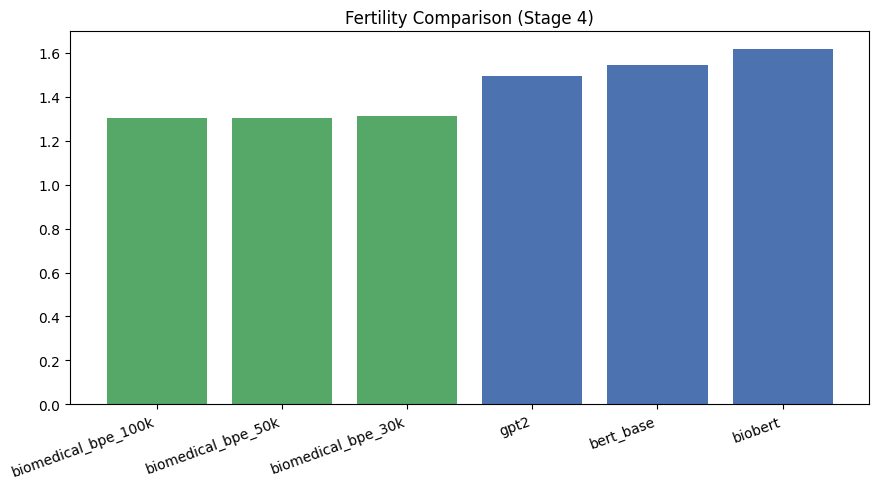

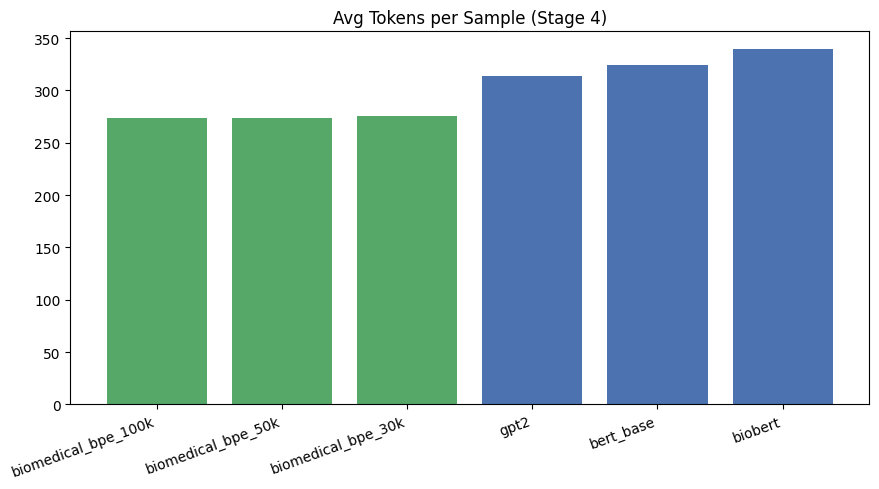

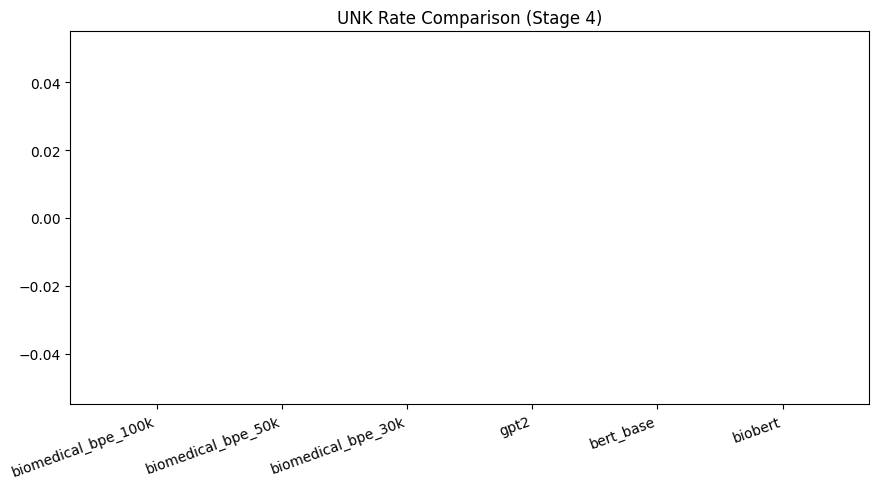

In [25]:
def plot_metric(metric_col, title):
    plt.figure(figsize=(9, 5))
    ordered = metrics_df.sort_values(by=metric_col)
    colors = ["#4C72B0" if fam == "baseline" else "#55A868" for fam in ordered["tokenizer_family"]]
    plt.bar(ordered["tokenizer_name"], ordered[metric_col], color=colors)
    plt.title(title)
    plt.xticks(rotation=20, ha="right")
    plt.tight_layout()
    plt.show()


plot_metric("fertility", "Fertility Comparison (Stage 4)")
plot_metric("avg_tokens_per_sample", "Avg Tokens per Sample (Stage 4)")
plot_metric("unk_rate", "UNK Rate Comparison (Stage 4)")

In [26]:
overlap_rows = []
baseline_vocab = set(baseline_tokenizers["biobert"].get_vocab().keys())

for name, tok in custom_tokenizers.items():
    custom_vocab = set(tok.get_vocab().keys())
    overlap = baseline_vocab.intersection(custom_vocab)
    overlap_rows.append(
        {
            "custom_tokenizer": name,
            "custom_vocab_size": len(custom_vocab),
            "biobert_vocab_size": len(baseline_vocab),
            "overlap_tokens": len(overlap),
            "overlap_ratio_vs_custom": len(overlap) / max(len(custom_vocab), 1),
        }
    )

overlap_df = pd.DataFrame(overlap_rows)
overlap_df

,custom_tokenizer,custom_vocab_size,biobert_vocab_size,overlap_tokens,overlap_ratio_vs_custom
0,biomedical_bpe_30k,30000,28996,8165,0.272167
1,biomedical_bpe_50k,39681,28996,9140,0.230337
2,biomedical_bpe_100k,39681,28996,9140,0.230337


In [27]:
print("Stage 4 metrics:")
display(metrics_df)

print("\nTerm split comparison by tokenizer:")
for tokenizer_name in metrics_df["tokenizer_name"].tolist():
    print(f"\n{tokenizer_name}")
    section = examples_df[examples_df["tokenizer_name"] == tokenizer_name][["term", "pieces", "n_pieces"]]
    display(section)

print("\nBaseline-custom vocabulary overlap:")
display(overlap_df)

print("\nTop 15 frequent tokens by tokenizer:")
for tokenizer_name in metrics_df["tokenizer_name"].tolist():
    print(f"\n{tokenizer_name}")
    top_df = pd.DataFrame(top_tokens_summary[tokenizer_name], columns=["token", "count"])
    display(top_df.head(15))

Stage 4 metrics:


,tokenizer_name,tokenizer_family,avg_tokens_per_sample,fertility,unk_rate,avg_token_length_chars,stage
5,biomedical_bpe_100k,custom,273.263333,1.301109,0.0,5.122096,stage4_tokenization_analysis
4,biomedical_bpe_50k,custom,273.263333,1.301109,0.0,5.122096,stage4_tokenization_analysis
3,biomedical_bpe_30k,custom,275.110000,1.309902,0.0,5.080566,stage4_tokenization_analysis
2,gpt2,baseline,313.383333,1.492136,0.0,5.010264,stage4_tokenization_analysis
0,bert_base,baseline,323.886667,1.542146,0.0,4.287131,stage4_tokenization_analysis
1,biobert,baseline,339.490000,1.616439,0.0,4.052037,stage4_tokenization_analysis



Term split comparison by tokenizer:

biomedical_bpe_100k


,term,pieces,n_pieces
50,nephrolithiasis,[nephrolithiasis],1
51,gastroesophageal,[gastroesophageal],1
52,dermographism,"[dermo, graph, ism]",3
53,electrocardiogram,[electrocardiogram],1
54,immunohistochemistry,[immunohistochemistry],1
55,acetylcholinesterase,[acetylcholinesterase],1
56,hypercholesterolemia,[hypercholesterolemia],1
57,hepatocellular,[hepatocellular],1
58,neurodegenerative,[neurodegenerative],1
59,myocardial,[myocardial],1



biomedical_bpe_50k


...

,token,count
0,.,3921
1,Ġof,2500
2,",",2404
3,Ġthe,2370
4,Ġand,2114
5,Ġ(,1657
6,-,1601
7,Ġin,1425
8,Ġto,1081
9,Ġwith,909



bert_base


,token,count
0,.,4469
1,the,2905
2,",",2772
3,of,2540
4,and,2123
5,),1763
6,(,1748
7,-,1728
8,in,1594
9,to,1195



biobert


,token,count
0,.,4469
1,the,2905
2,",",2772
3,of,2540
4,and,2123
5,),1763
6,(,1748
7,-,1728
8,in,1717
9,to,1223
